# Implementation of BMOCZ + SIC
Channel Model: Complex Slow Fading

In [1]:
import numpy as np
from scipy.linalg import toeplitz,dft
import matplotlib.pyplot as plt

In [2]:
def toeplitz_iterator(zeros):

    for k in range(len(zeros)):
        if k == 0:
            c = np.array([[1, -zeros[k]]]).T   # (z-alpha)
        else:
            column = np.zeros(k+2, dtype=complex)
            column[0] = 1
            column[1] = -zeros[k]

            row = np.zeros(k+1, dtype=complex)
            row[0] = 1

            T = toeplitz(column, row)

            c = T @ c
            x = c.flatten()

    return x[::-1]

In [3]:
def codebook_con(R, K):

    Ri, Ro = R**(-1), R
    theta_k = (2 * np.pi)/K

    zero_cb = [( Ri * np.exp(1j*theta_k*k), Ro * np.exp(1j*theta_k*k) ) for k in range(K)]

    return zero_cb

In [4]:
def coeffCon(msg):
    K = len(msg)
    R = np.sqrt( 1 + np.sin(np.pi/K) )
    theta_k = (np.pi * 2)/K

    zero_geometry = codebook_con(R, K)

    zeros = [zero_geometry[mk][msg[mk]] for mk in range(K)]
    print(f'\nZeroes selected wrt to message to be transmitted: {np.round(zeros, 6)}\n')
    
    x = toeplitz_iterator(zeros)     # x = [ x0, x1, x2, ....., xK]
    
    return x

In [5]:
K = 2 ** np.random.randint(1, 4)
print(f'Number of message bits to be transmitted: {K}')

message = [np.random.randint(2) for i in range(K)]
print(f'The message to be transmitted: {message}')

x = coeffCon(message)
print(f"The transmitted sequence will be: {x}")

# R = np.sqrt(1 + np.sin(np.pi / K))
# Ri, Ro = R**(-1), R

# print(f'Radius of inner circle: {Ri}')
# print(f'Radius of outer circle: {Ro}')

Number of message bits to be transmitted: 4
The message to be transmitted: [1, 0, 0, 0]

Zeroes selected wrt to message to be transmitted: [ 1.306563+0.j        0.      +0.765367j -0.765367+0.j
 -0.      -0.765367j]

The transmitted sequence will be: [-0.58578644+2.15214446e-16j -0.31702534+2.22044605e-16j
 -0.41421356-5.55111512e-17j -0.5411961 -1.11022302e-16j
  1.        +0.00000000e+00j]


# Channel

In [6]:
# channel variance
p = np.random.uniform(0,1)
print(f'Complex channel variance: {p}')
h_com = np.sqrt(p/2)*np.random.randn(1) + 1j*np.sqrt(p/2)*np.random.randn(1) 
print(f'Flat fading channel coefficient: {h_com}')
h_mag = np.abs(h_com)
h_phase = np.angle(h_com)/(2*np.pi)
print(f'Attenuation: {np.round(h_mag, 6)}, rotation: {np.round(h_phase, 6)}(in degrees) applied by channel')

Complex channel variance: 0.8659987912510274
Flat fading channel coefficient: [-1.07482406+1.56278158j]
Attenuation: [1.896716], rotation: [0.345885](in degrees) applied by channel


# Receiver

In [7]:
def fftCon(y, K, Q, R):
    N_r = len(y)
    N_fft = Q * K

    scaling_vec = R ** np.arange(N_r)
    y_ctr = np.conjugate(y[::-1])

    y_scaled = y * scaling_vec
    y_ctr_scaled = y_ctr * scaling_vec

    y_pad = np.pad(y_scaled, (0, N_fft - N_r), mode='constant')
    y_ctr_pad = np.pad(y_ctr_scaled, (0, N_fft - N_r), mode='constant')

    Y_eval = np.abs( np.fft.ifft(y_pad) )
    Y_ctr_eval = np.abs( np.fft.ifft(y_ctr_pad) )

    return Y_eval, Y_ctr_eval

In [8]:
def ffo_est(y, Q, K, R):
    
    Yo, Yi = fftCon(y, K, Q, R)
    theta_k = (2 * np.pi) / K
    min_q = {}
    for q in range(Q):
        sumZeros = 0
        for k in range(K):
            idx = (Q * k + q) % len(Yo)
            sumZeros += min( np.abs(Yi[idx]), np.abs(Yo[idx]) )
        min_q[q] = sumZeros
    q_est= np.argmin(min_q)
    print(f'Estimatied sub-sector: {q_est}')
    theta_est = ( q_est / Q ) * theta_k
    print(f'Estimated fractional frequency offset: {theta_est}') 
    return theta_est

In [9]:
def fftDizet(y, K, Q, R):
    Y_eval, Y_ctr_eval = fftCon(y, K, Q, R)

    message_received = ( 1 - np.sign( Y_eval[::Q] - Y_ctr_eval[::Q] ) ) / 2 

    return message_received

In [10]:
y_com = x * h_com
print(f'Received sequence through complex slow fading channel without noise: {y_com}')

Q = int( 2**( np.log( np.ceil( len(y_com) / K ) ) / np.log(2) ) )
R = np.sqrt(1 + np.sin(np.pi/K))

# codebook construction at RX for REFERENCE
zero_geometry = codebook_con(R, K)

theta_est = ffo_est(y_com, Q, K, R)

# fractional offset correction
M_theta = np.diag( np.exp(-1j*theta_est) ** np.arange(len(y_com)) )
# print(M_theta)
y_ffo = y_com @ M_theta
# print(y_ffo)

#  Ro = np.sqrt(1 + np.sin(np.pi/K))
msg_RxS1 = fftDizet(y_ffo, K, Q, R)     
msg_RxS1 = np.array(msg_RxS1, dtype=int)
# print(msg_RxS1)

ber = np.mean(message != msg_RxS1)
print(f'BER: {ber}')
print(message)

Received sequence through complex slow fading channel without noise: [ 0.62961735-0.91545626j  0.34074646-0.49544136j  0.4452067 -0.64732533j
  0.58169059-0.8457713j  -1.07482406+1.56278158j]
Estimatied sub-sector: 0
Estimated fractional frequency offset: 0.0
BER: 0.0
[1, 0, 0, 0]


# Channel Estimation

In [11]:
coeff_reconS1 = coeffCon(msg_RxS1)

h_est = y_com / coeff_reconS1

print(f'Estimated channel coefficients: {h_est}')

print(f'\nComplex slow fading channel used: {h_com}')


Zeroes selected wrt to message to be transmitted: [ 1.306563+0.j        0.      +0.765367j -0.765367+0.j
 -0.      -0.765367j]

Estimated channel coefficients: [-1.07482406+1.56278158j -1.07482406+1.56278158j -1.07482406+1.56278158j
 -1.07482406+1.56278158j -1.07482406+1.56278158j]

Complex slow fading channel used: [-1.07482406+1.56278158j]


# SIC

- We estimated channel coefficients from the slot-1 

- we reconstruct the coefficients of the polynomial to be transmitted using the decodes bits(symbols) 

- We can cel the interference from the slot-2 and decode another message from the slot.

In [12]:
message2 = [np.random.randint(2) for i in range(K)]
print(f'The message to be transmitted: {message2}')

x2 = coeffCon(message2)
print(f"The transmitted sequence will be: {x2}")

The message to be transmitted: [0, 1, 0, 1]

Zeroes selected wrt to message to be transmitted: [ 0.765367+0.j        0.      +1.306563j -0.765367+0.j
 -0.      -1.306563j]

The transmitted sequence will be: [-1.00000000e+00+3.67394040e-16j -1.45057629e-16-2.22044605e-16j
  1.12132034e+00-3.47625755e-16j  1.28989420e-16+0.00000000e+00j
  1.00000000e+00+0.00000000e+00j]


In [13]:
y_U2 = x2 * h_com
print(f'Received sequence through complex slow fading channel without noise: {y_U2}')

Q = int( 2**( np.log( np.ceil(len(y_U2/K)) ) / np.log(2) ) )
R = np.sqrt(1 + np.sin(np.pi/K))

# codebook construction at RX for REFERENCE
zero_geometry = codebook_con(R, K)

theta_est = ffo_est(y_U2, Q, K, R)

# fractional offset correction
M_theta = np.diag( np.exp(-1j*theta_est) ** np.arange(len(y_U2)) )
# print(M_theta)
y_ffoS2 = y_U2 @ M_theta
# print(y_ffo)

#  Ro = np.sqrt(1 + np.sin(np.pi/K))
msg_RxU2 = fftDizet(y_ffoS2, K, Q, R)     
msg_RxU2 = np.array(msg_RxU2, dtype=int)
# print(msg_RxU2)

ber = np.mean(message2 != msg_RxU2)
print(f'BER: {ber}')
print(message2)

Received sequence through complex slow fading channel without noise: [ 1.07482406e+00-1.56278158e+00j  5.02918648e-16+1.19654925e-17j
 -1.20522208e+00+1.75237878e+00j -1.38640932e-16+2.01582291e-16j
 -1.07482406e+00+1.56278158e+00j]
Estimatied sub-sector: 0
Estimated fractional frequency offset: 0.0
BER: 0.0
[0, 1, 0, 1]


## Slot-2: Interference of U1 and U2

In [14]:
yS2 = x * h_com + x2 * h_com
print(f'Received sequence through complex slow fading channel without noise: {yS2}')

Received sequence through complex slow fading channel without noise: [ 1.70444141-2.47823784j  0.34074646-0.49544136j -0.76001538+1.10505345j
  0.58169059-0.8457713j  -2.14964811+3.12556316j]


## Interference Cancellation

In [15]:
y2_IC = yS2 - coeff_reconS1 * h_com

Q = int( 2**( np.log( np.ceil(len(y2_IC/K)) ) / np.log(2) ) )
R = np.sqrt(1 + np.sin(np.pi/K))

# codebook construction at RX for REFERENCE
zero_geometry = codebook_con(R, K)

theta_est = ffo_est(y2_IC, Q, K, R)

# fractional offset correction
M_theta = np.diag( np.exp(-1j*theta_est) ** np.arange(len(y2_IC)) )
# print(M_theta)
y_ffo = y2_IC @ M_theta
# print(y_ffo)

#  Ro = np.sqrt(1 + np.sin(np.pi/K))
msg_Rx2 = fftDizet(y_ffo, K, Q, R)     
msg_Rx2 = np.array(msg_Rx2, dtype=int)
# print(msg_Rx_ffo)

ber = np.mean(message2 != msg_Rx2)
print(msg_Rx2)
print(f'BER: {ber}')
print(message2)

Estimatied sub-sector: 0
Estimated fractional frequency offset: 0.0
[0 1 0 1]
BER: 0.0
[0, 1, 0, 1]


### Trying the rayleigh distibution for channel to see if we can rotate the zeros across the sectors

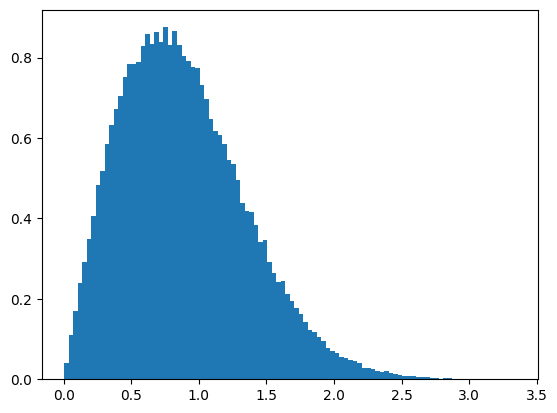

In [16]:
import numpy as np
import matplotlib.pyplot as plt

h = (np.random.randn(100000) +
     1j*np.random.randn(100000))/np.sqrt(2)

plt.hist(np.abs(h), bins=100, density=True)
plt.show()

In [17]:
h_mag = np.random.rayleigh(scale=1.0)
print(h_mag)

0.5611741169370686


In [18]:
sigma = 1/np.sqrt(2)

h = sigma * (
    np.random.randn() +
    1j * np.random.randn()
)
print(h, abs(h), np.angle(h))

(-0.38328091269859144+0.14768155908160208j) 0.410748220850484 2.7738147875900085


In [19]:
theta = 180 * np.angle(h) / (2*np.pi)
print(abs(h) * np.exp(1j * theta))
x = 1 + 1j
print(180 * np.angle(x)/(np.pi))

(-0.24748978198116375-0.3278153577042327j)
45.0
